# 09. Heteroevaluación disponible

**Fuente:** `data/raw/heteroevaluaciondisponible.csv`  
**Salida:** `data/processed/heteroevaluacion_disponible.csv`

Resultados de evaluacion docente por curso/paralelo/periodo (promedio, numero de evaluados). El archivo de origen trae la columna ANIO duplicada por un join previo.

In [29]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [30]:
df = pc.leer_csv('heteroevaluaciondisponible.csv', low_memory=False)
df.head()

Leido heteroevaluaciondisponible.csv con encoding=utf-8-sig -> 76645 filas, 16 columnas


,ANIO,TERMINO,UNIDAD,IDCURSO,IDPERSONA,CODIGOMATERIA,ANIO.1,PARALELO,MATERIA,TIPOCURSO,IDENTIFICACION,APELLIDOS,NOMBRES,PROMEDIO,REGISTRADOS,EVALUADOS
0,2020,2S,FIMCP,142992.0,2834.0,MTRG1038,2020,1,SÍNTESIS DE MATERIALES,P,0920054202,PERUGACHI BENALCAZAR,CESAR RODRIGO,49.28,11,8
1,2020,2S,FIMCP,144371.0,1577.0,MTRG1028,2020,1,ESTRUCTURA Y CARACTERIZACIÓN DE MATERIALES,P,0914200290,CORNEJO MARTINEZ,MAURICIO HERIBERTO,89.00,12,10
2,2020,2S,FICT,138568.0,2161.0,MING1032,2020,101,"VENTILACIÓN, DRENAJE Y SISTEMAS ELÉCTRICOS",G,0917260853,ROMERO CRESPO,PAOLA LEONOR,99.64,5,4
3,2020,2S,FICT,138559.0,2103.0,MING1032,2020,1,"VENTILACIÓN, DRENAJE Y SISTEMAS ELÉCTRICOS",P,0917010332,CRESPO QUINTERO,JESÚS WASHINGTON,88.57,5,4
4,2020,2S,FCSH,144714.0,452.0,ARQG2043,2020,1,CAMPO DE ARQUEOLOGÍA II,P,0902282656,MARCOS PINO,JORGE GABRIEL,100.00,3,3


## 2. Exploración inicial

In [18]:
pc.resumen(df, 'heteroevaluacion_disponible')

--- Resumen heteroevaluacion_disponible ---
Dimensiones: 76645 filas x 16 columnas
Filas duplicadas: 1
Columnas con nulos (%):
IDCURSO      63.4
IDPERSONA     0.1
APELLIDOS     0.0
NOMBRES       0.0
dtype: float64


In [19]:
df.dtypes

ANIO                int64
TERMINO            object
UNIDAD             object
IDCURSO           float64
IDPERSONA         float64
CODIGOMATERIA      object
ANIO.1              int64
PARALELO           object
MATERIA            object
TIPOCURSO          object
IDENTIFICACION     object
APELLIDOS          object
NOMBRES            object
PROMEDIO          float64
REGISTRADOS         int64
EVALUADOS           int64
dtype: object

## 3. Limpieza

In [20]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df)
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Filas duplicadas eliminadas: {n_antes - len(df)}')

Filas duplicadas eliminadas: 1


## 5. Tipado de fechas e identificadores

In [21]:
df = pc.castear_enteros(df, ['IDCURSO', 'IDPERSONA'])

## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Distribución del promedio de heteroevaluación** por curso/paralelo.

<Axes: title={'center': 'Distribución del promedio de heteroevaluación'}>

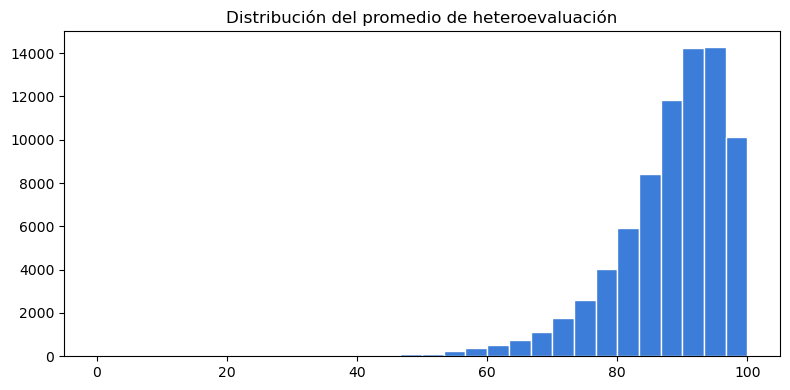

In [23]:
pc.grafico_histograma(df['PROMEDIO'], 'Distribución del promedio de heteroevaluación', bins=30, recorte_percentil=None)

**Heteroevaluaciones registradas por año**.

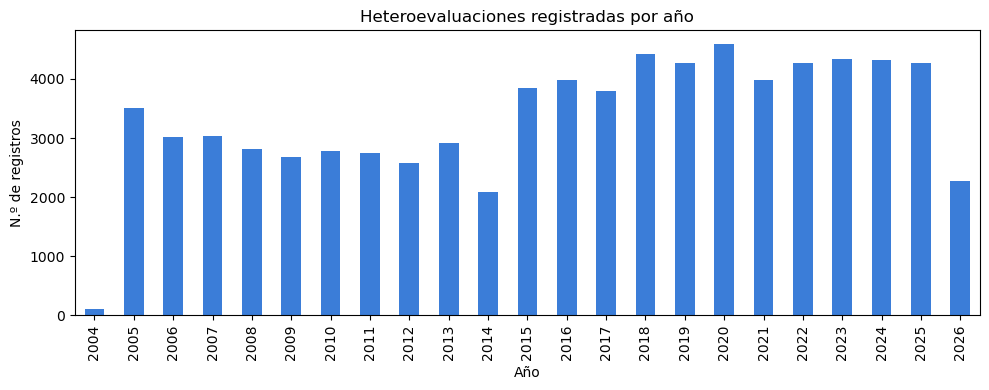

In [24]:
conteo_anio = df['ANIO'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
conteo_anio.plot(kind='bar', ax=ax, color=pc.COLOR_PRINCIPAL)
ax.set_title('Heteroevaluaciones registradas por año')
ax.set_xlabel('Año'); ax.set_ylabel('N.º de registros')
plt.tight_layout()

**Unidades con más heteroevaluaciones registradas**.

<Axes: title={'center': 'Top 10 unidades por N.º de heteroevaluaciones'}, ylabel='UNIDAD'>

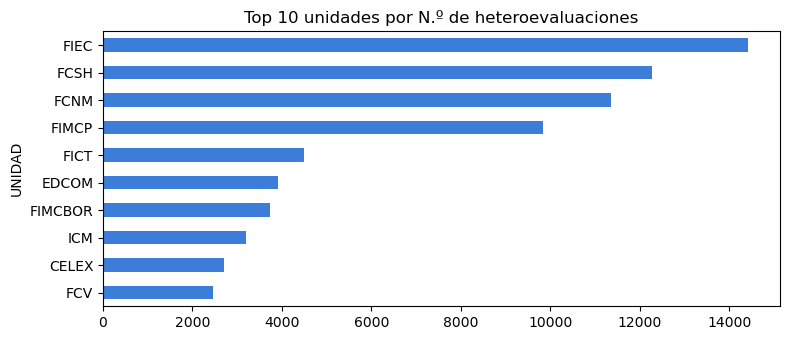

In [25]:
pc.grafico_barras(df['UNIDAD'], 'Top 10 unidades por N.º de heteroevaluaciones', top=10)

**Tasa de participación** (evaluados / registrados) por curso: variable derivada útil para medir el compromiso estudiantil detrás de cada promedio.

<Axes: title={'center': 'Tasa de participación (evaluados / registrados)'}>

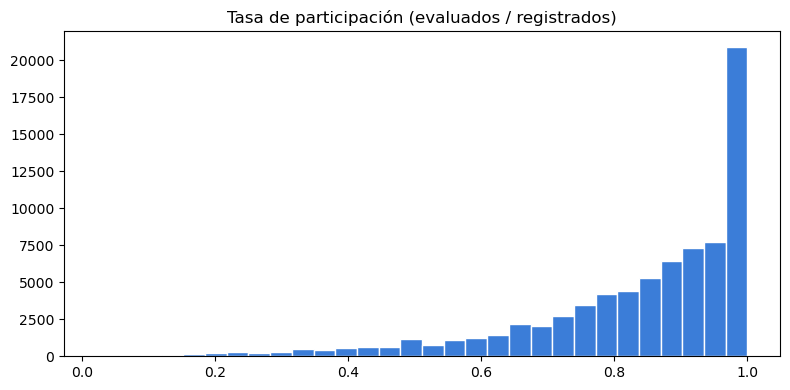

In [26]:
tasa_participacion = (df['EVALUADOS'] / df['REGISTRADOS']).replace([float('inf')], pd.NA)
pc.grafico_histograma(tasa_participacion, 'Tasa de participación (evaluados / registrados)', bins=30, recorte_percentil=None)

## 7. Verificación final

In [27]:
pc.resumen(df, 'heteroevaluacion_disponible (procesado)')
df.head()

--- Resumen heteroevaluacion_disponible (procesado) ---
Dimensiones: 76644 filas x 16 columnas
Filas duplicadas: 0
Columnas con nulos (%):
IDCURSO      63.4
IDPERSONA     0.1
APELLIDOS     0.0
NOMBRES       0.0
dtype: float64


,ANIO,TERMINO,UNIDAD,IDCURSO,IDPERSONA,CODIGOMATERIA,ANIO.1,PARALELO,MATERIA,TIPOCURSO,IDENTIFICACION,APELLIDOS,NOMBRES,PROMEDIO,REGISTRADOS,EVALUADOS
0,2020,2S,FIMCP,142992,2834,MTRG1038,2020,1,SÍNTESIS DE MATERIALES,P,0920054202,PERUGACHI BENALCAZAR,CESAR RODRIGO,49.28,11,8
1,2020,2S,FIMCP,144371,1577,MTRG1028,2020,1,ESTRUCTURA Y CARACTERIZACIÓN DE MATERIALES,P,0914200290,CORNEJO MARTINEZ,MAURICIO HERIBERTO,89.00,12,10
2,2020,2S,FICT,138568,2161,MING1032,2020,101,"VENTILACIÓN, DRENAJE Y SISTEMAS ELÉCTRICOS",G,0917260853,ROMERO CRESPO,PAOLA LEONOR,99.64,5,4
3,2020,2S,FICT,138559,2103,MING1032,2020,1,"VENTILACIÓN, DRENAJE Y SISTEMAS ELÉCTRICOS",P,0917010332,CRESPO QUINTERO,JESÚS WASHINGTON,88.57,5,4
4,2020,2S,FCSH,144714,452,ARQG2043,2020,1,CAMPO DE ARQUEOLOGÍA II,P,0902282656,MARCOS PINO,JORGE GABRIEL,100.00,3,3


## 8. Guardado en data/processed

In [28]:
pc.guardar_procesado(df, 'heteroevaluacion_disponible.csv')

Guardado: D:\Proyecto_Tesis\data\processed\heteroevaluacion_disponible.csv (76644 filas x 16 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/heteroevaluacion_disponible.csv')